# Quantile shift analysis -- does retraining move the forecaster's predicted quantiles?

Re-run against the retrain campaign completed 2026-08-24 (seeding-bug fix --
`np.random.seed(cfg.seed)` was missing from `train_one_config`; batch_size 8->64,
max_epochs 20->200, patience 5->10, matching the original baseline forecaster's own
convention; 1-stage dual-price's epigraph dropped for training since it's provably inert
for the decision -- see `7_model_training/dfl_train_utils.py`). Identical methodology to
the archived original at `Z_archive/pre_final_train/quantile_shift_analysis.ipynb` --
only the checkpoints underneath have changed.

Scope: every other comparison in this project's `8_testing/` notebooks looks at the
forecaster's derived MEAN (`pl_hat`, via the copula) -- accuracy (MAE), bias, and the
economic evaluations all operate on that single summary statistic. This notebook asks a
different, more basic question: does DFL/CRPS-only retraining move the underlying
**quantile forecast itself** (all Q=19 levels, `forecasting.QUANTILE_LEVELS`), and if so,
does it move every quantile level roughly equally (a pure level/mean shift, spread
preserved) or does it reshape the predictive distribution (compressing/widening the
spread, or moving some quantile levels more than others)?

Method: for each forecaster, average the raw quantile forecast `q_phys` (K=24 leads, Q=19
levels) over every test day AND every hour, collapsing time entirely to isolate the
quantile-level axis -- producing one (19,) curve per forecaster. Retrained forecasters
(CRPS-only control, DFL single-price, DFL dual-price) are seed-averaged (N=5, same seeds/
convention as the rest of this project -- see `9_analysis/why_dfl_helps.md` Part 3);
baseline stays a single fixed curve (not seed-averaged, by the project's established
convention). No dispatch/copula-mean machinery involved at all here -- this is purely
about the forecaster's own output, upstream of anything the copula or dispatch layer does
with it.

In [1]:
from __future__ import annotations
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR,
)
from forecasting import QUANTILE_LEVELS

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


print("loading test windows...")
windows = load_test_windows()

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)


print(f"n_test_days={len(windows.delivery_start)}  n_quantile_levels={len(QUANTILE_LEVELS)}")

loading test windows...


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_test_days=366  n_quantile_levels=19


## Average quantile curve per forecaster (all test days/hours collapsed)

In [2]:
def avg_quantile_curve(model):
    """(Q,) -- mean quantile forecast across every test day AND every hour, per
    quantile level. Collapses the day/hour axes entirely; only the quantile-level axis
    survives."""
    total = np.zeros(len(QUANTILE_LEVELS))
    n = 0
    for d in range(len(windows.delivery_start)):
        q_phys = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d]).numpy()  # (24, 19)
        total += q_phys.sum(axis=0)
        n += q_phys.shape[0]
    return total / n


def avg_quantile_across_seeds(base_id):
    """(mean (Q,), std (Q,)) across the 5 seeds -- same seed-averaging convention as
    every other multi-seed comparison in this project."""
    curves = np.array([avg_quantile_curve(load_dfl(seed_variant(base_id, seed))) for seed in SEEDS])
    return curves.mean(axis=0), curves.std(axis=0)


baseline_curve = avg_quantile_curve(baseline_model)
crps_only_mean, crps_only_std = avg_quantile_across_seeds("crps_only_retrained")
dfl_single_mean, dfl_single_std = avg_quantile_across_seeds("dfl_1stage_single-price")
dfl_dual_mean, dfl_dual_std = avg_quantile_across_seeds("dfl_1stage_dual-price")

print("baseline curve:", np.round(baseline_curve, 3))
print("done computing quantile curves")

baseline curve: [1.582 1.716 1.802 1.863 1.926 1.992 2.053 2.098 2.133 2.21  2.222 2.298
 2.32  2.405 2.422 2.511 2.573 2.678 2.839]
done computing quantile curves


## Plot -- raw quantile curve (top row) and shift vs baseline (bottom row)

Top row: the actual average predicted value at each quantile level, baseline (fixed line)
vs each retrained forecaster (mean +/- std band across N=5 seeds). If retraining only
shifts the forecaster's level/mean, every point on a retrained curve should sit a roughly
CONSTANT distance above or below baseline's curve -- i.e. the two curves should look like
parallel lines. If retraining reshapes the distribution instead (compressing/widening
spread, or moving some quantile levels more than others), the vertical gap between the two
curves will change across quantile levels rather than staying constant.

Bottom row: the same comparison made precise -- `retrained_quantile - baseline_quantile`
at each level. A flat horizontal line at some nonzero value means "pure level shift,
spread unchanged". A sloped or curved line means quantiles are moving by different amounts
-- e.g. tails moving one way and the median another means retraining is narrowing or
widening the predictive spread, not just shifting it. Both rows share their own y-axis
across the three panels and carry horizontal reference gridlines, matching this project's
established comparison-plot convention (`forecast_characteristics.ipynb` Sections 10c/10d).

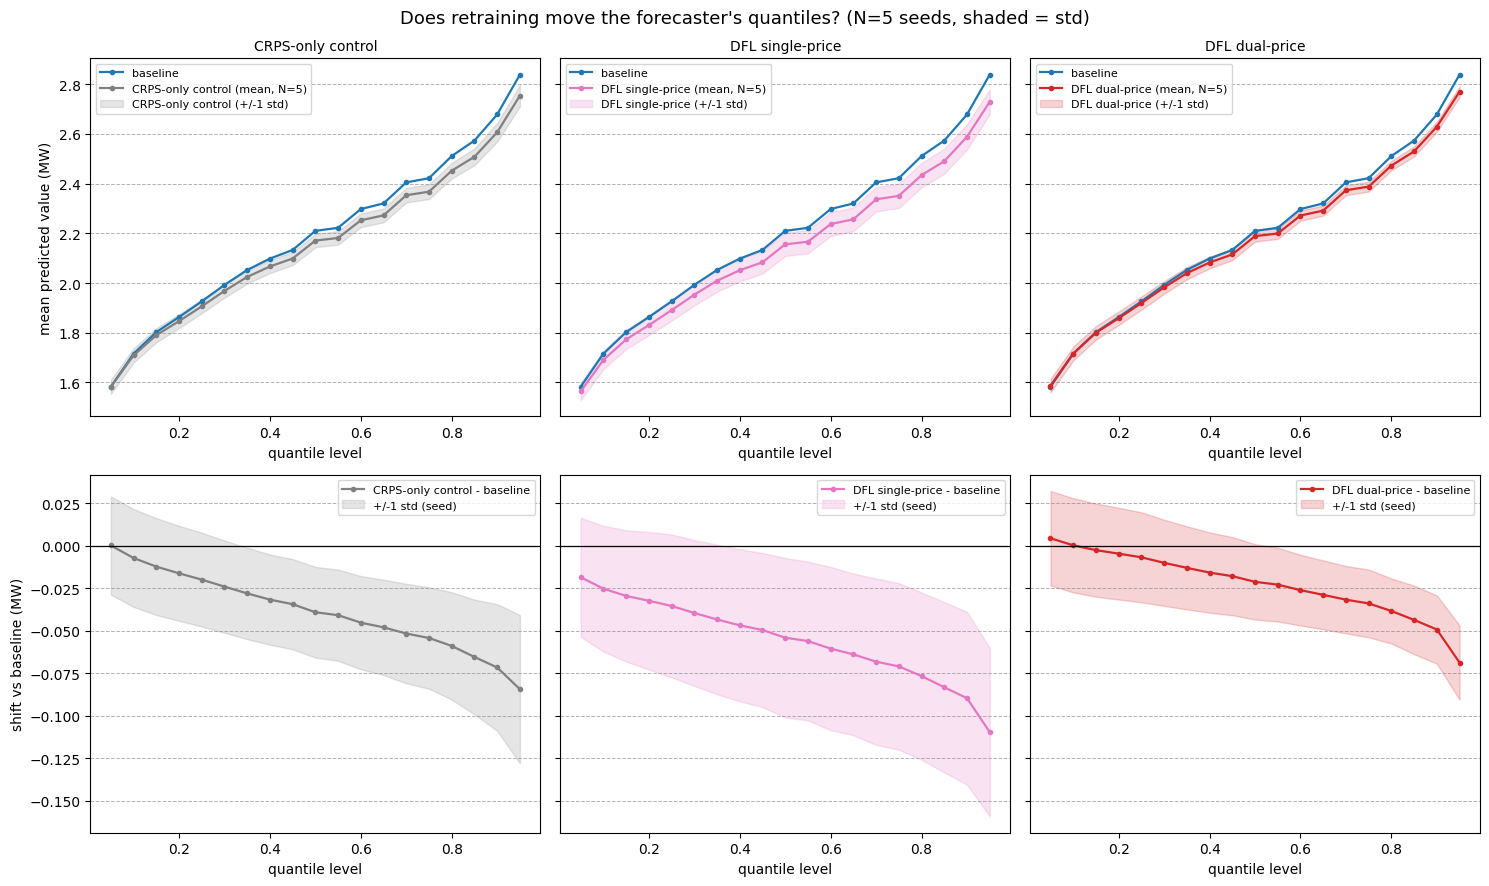

In [3]:
colors = {"baseline": "C0", "CRPS-only control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}
panels = [
    ("CRPS-only control", crps_only_mean, crps_only_std),
    ("DFL single-price", dfl_single_mean, dfl_single_std),
    ("DFL dual-price", dfl_dual_mean, dfl_dual_std),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey="row")
q = QUANTILE_LEVELS

for ax, (label, mean, std) in zip(axes[0], panels):
    ax.plot(q, baseline_curve, "-o", color=colors["baseline"], markersize=3, label="baseline", linewidth=1.6)
    ax.plot(q, mean, "-o", color=colors[label], markersize=3, label=f"{label} (mean, N=5)", linewidth=1.6)
    ax.fill_between(q, mean - std, mean + std, color=colors[label], alpha=0.2, label=f"{label} (+/-1 std)")
    ax.grid(axis="y", linestyle="--", linewidth=0.7, color="grey", alpha=0.6, zorder=0)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("quantile level")
    ax.legend(fontsize=8, loc="best")
axes[0, 0].set_ylabel("mean predicted value (MW)")

for ax, (label, mean, std) in zip(axes[1], panels):
    shift = mean - baseline_curve
    ax.plot(q, shift, "-o", color=colors[label], markersize=3, label=f"{label} - baseline", linewidth=1.6)
    ax.fill_between(q, shift - std, shift + std, color=colors[label], alpha=0.2, label="+/-1 std (seed)")
    ax.axhline(0, color="black", linewidth=0.9, zorder=2)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, color="grey", alpha=0.6, zorder=0)
    ax.set_xlabel("quantile level")
    ax.legend(fontsize=8, loc="best")
axes[1, 0].set_ylabel("shift vs baseline (MW)")

fig.suptitle("Does retraining move the forecaster's quantiles? (N=5 seeds, shaded = std)", fontsize=13)
fig.tight_layout()
plt.show()